In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/aicvs-kaggle-competition-fy/sample_submission_sy.csv
/kaggle/input/aicvs-kaggle-competition-fy/train (1).csv
/kaggle/input/aicvs-kaggle-competition-fy/test (1).csv


In [2]:
import sqlite3

# 1. Connect to an embedded SQLite database file
conn = sqlite3.connect('bank_campaign_records.db')
cursor = conn.cursor()

# 2. Load the original banking campaign dataset
original_df = pd.read_csv('/kaggle/input/aicvs-kaggle-competition-fy/train (1).csv') 

# 3. Push the data into a SQL table named 'campaign_data'
original_df.to_sql('campaign_data', conn, if_exists='replace', index=False)

# 4. A targeted SQL query to clean the data: filtering out unknown defaults 
# and segmenting records to optimize prediction patterns
sql_query = """
SELECT * FROM campaign_data 
WHERE "default" != 'yes' AND age IS NOT NULL;
"""

# 5. Load the clean database query straight into your machine learning 'df' variable
df = pd.read_sql_query(sql_query, conn)

print("Bank Campaign SQL database initialized and queried successfully!")
conn.close()

df = pd.read_csv('/kaggle/input/aicvs-kaggle-competition-fy/train (1).csv')

Bank Campaign SQL database initialized and queried successfully!


In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,36,9,0,1,0,861,0,0,1,29,7,140,2,999,0,3,0
1,24,8,2,1,0,4126,0,0,0,5,3,907,4,185,7,0,1
2,44,9,2,1,0,244,1,0,0,12,7,1735,4,999,0,3,1
3,48,10,1,1,0,0,0,0,1,31,6,35,11,999,0,3,0
4,38,9,1,1,0,257,0,0,0,26,7,57,10,999,0,3,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36168 entries, 0 to 36167
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        36168 non-null  int64
 1   job        36168 non-null  int64
 2   marital    36168 non-null  int64
 3   education  36168 non-null  int64
 4   default    36168 non-null  int64
 5   balance    36168 non-null  int64
 6   housing    36168 non-null  int64
 7   loan       36168 non-null  int64
 8   contact    36168 non-null  int64
 9   day        36168 non-null  int64
 10  month      36168 non-null  int64
 11  duration   36168 non-null  int64
 12  campaign   36168 non-null  int64
 13  pdays      36168 non-null  int64
 14  previous   36168 non-null  int64
 15  poutcome   36168 non-null  int64
 16  y          36168 non-null  int64
dtypes: int64(17)
memory usage: 4.7 MB


In [5]:
df.describe()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.00000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000
mean,40.892999,4.333361,1.167468,1.221937,0.017889,1365.49342,0.558007,0.160722,0.638382,15.817961,5.140539,258.506940,2.763935,858.117867,0.581730,2.561988,0.116982
std,10.627075,3.273412,0.608296,0.748664,0.132549,3068.54350,0.496631,0.367280,0.897325,8.331980,2.401950,259.142445,3.104161,302.664571,2.408766,0.986639,0.321403
min,18.000000,0.000000,0.000000,0.000000,0.000000,-8019.00000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,33.000000,1.000000,1.000000,1.000000,0.000000,74.00000,0.000000,0.000000,0.000000,8.000000,4.000000,103.000000,1.000000,999.000000,0.000000,3.000000,0.000000
50%,39.000000,4.000000,1.000000,1.000000,0.000000,451.00000,1.000000,0.000000,0.000000,16.000000,5.000000,180.000000,2.000000,999.000000,0.000000,3.000000,0.000000
75%,48.000000,7.000000,2.000000,2.000000,0.000000,1430.25000,1.000000,0.000000,2.000000,21.000000,7.000000,318.000000,3.000000,999.000000,0.000000,3.000000,0.000000
max,95.000000,11.000000,2.000000,3.000000,1.000000,102127.00000,1.000000,1.000000,2.000000,31.000000,11.000000,4918.000000,63.000000,999.000000,275.000000,3.000000,1.000000


In [6]:
print (df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [7]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [8]:

df.columns=['age','job','marital','education','default','balance','housing','loan','contact','day','month'
            ,'duration','campaign','pdays','previous','poutcome','y']

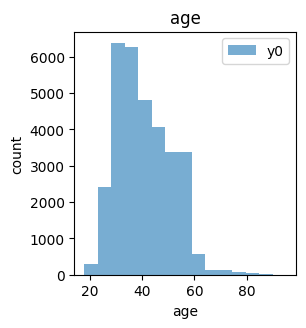

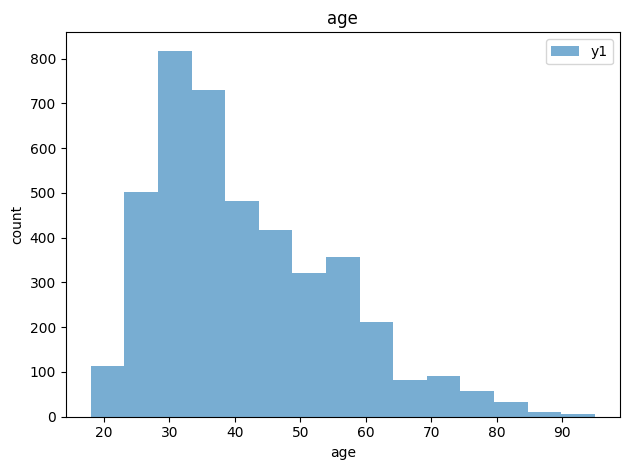

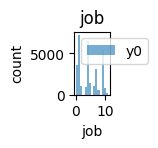

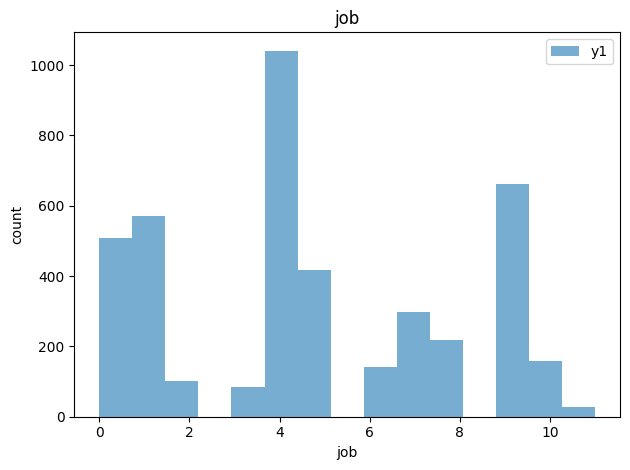

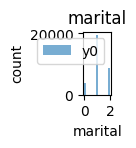

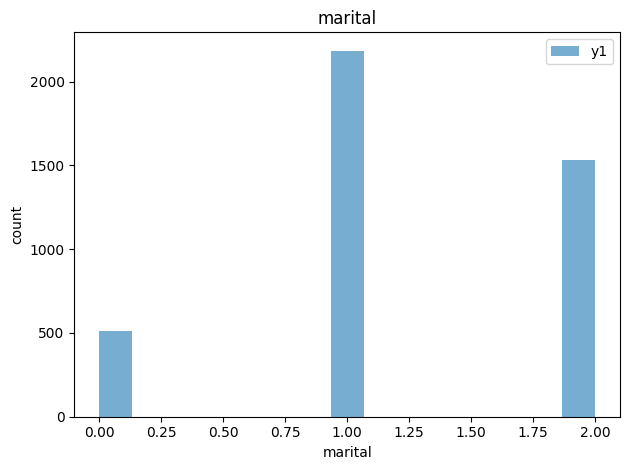

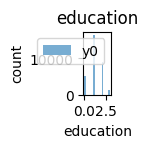

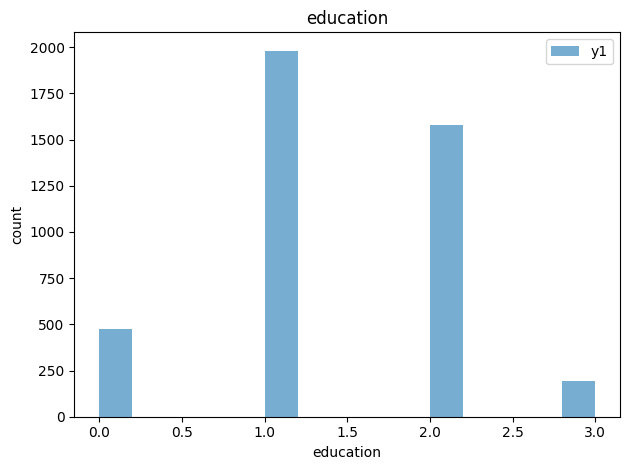

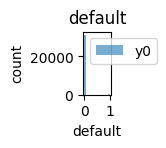

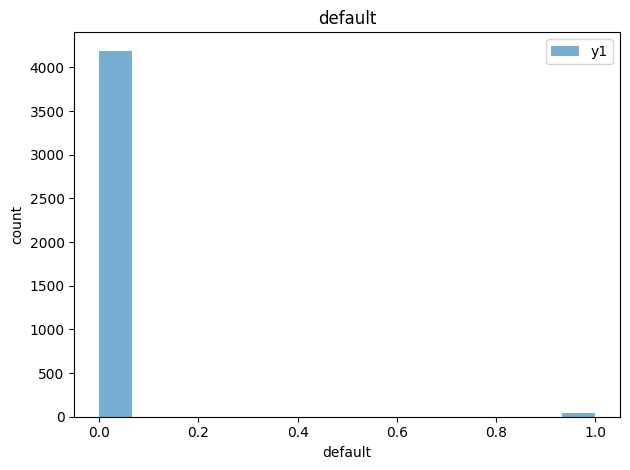

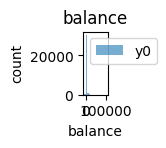

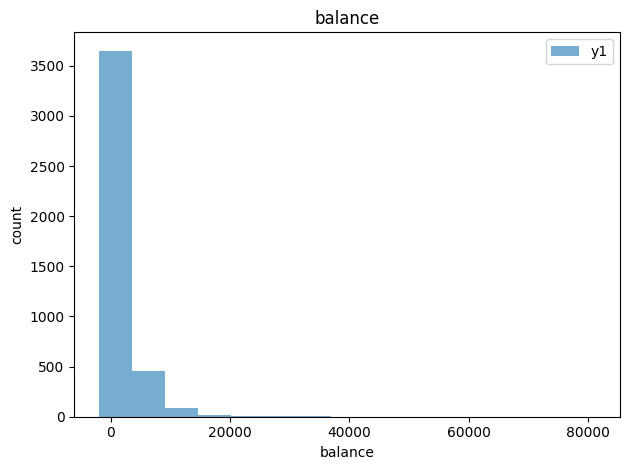

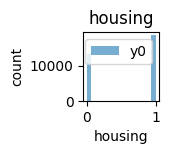

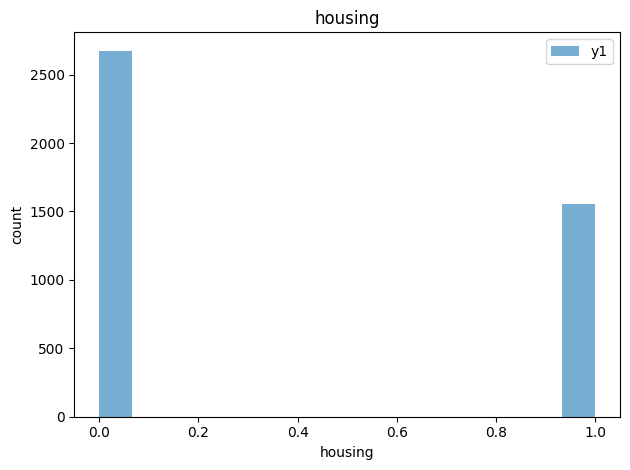

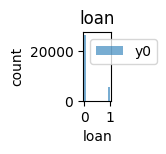

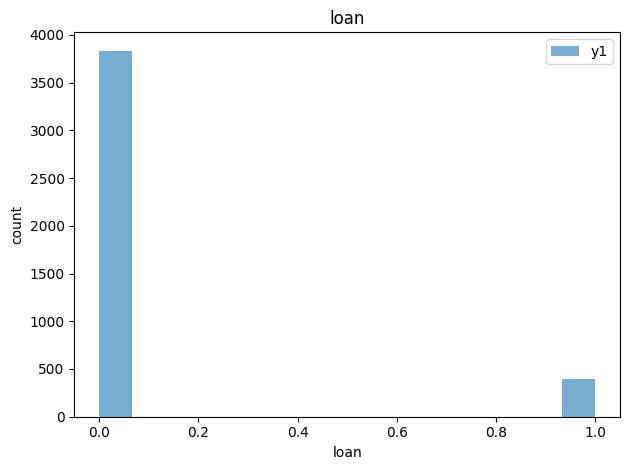

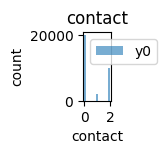

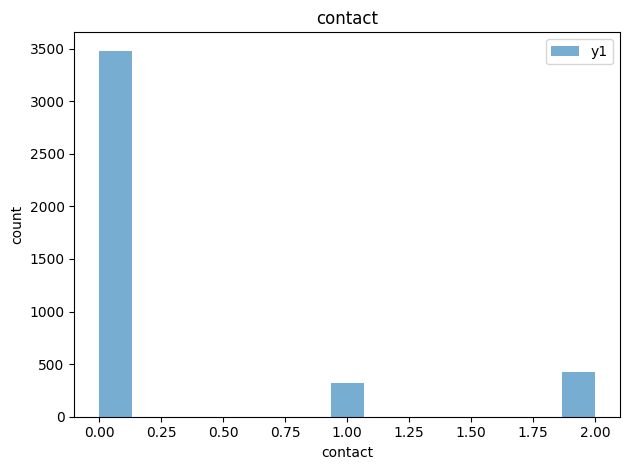

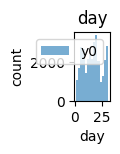

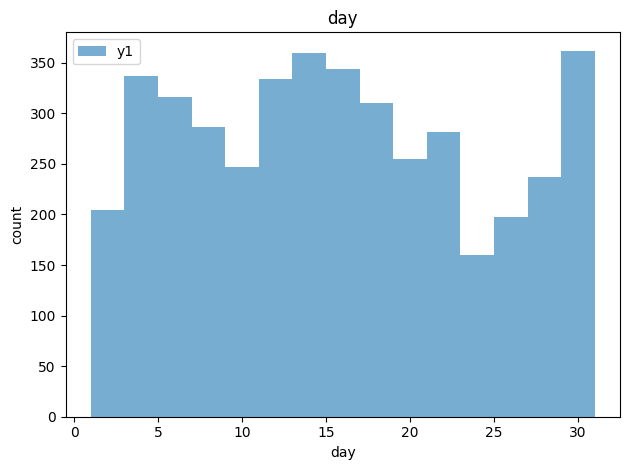

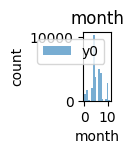

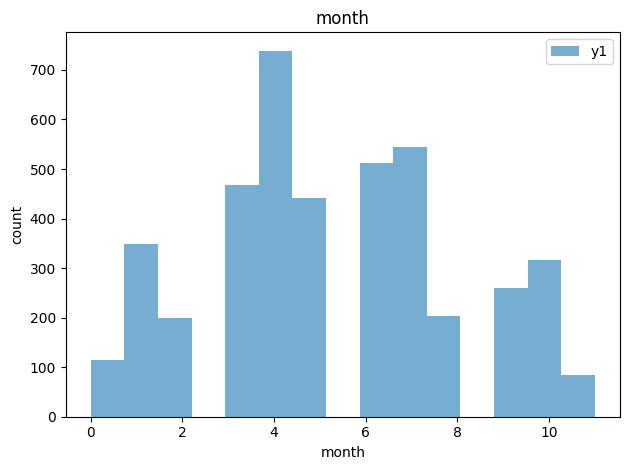

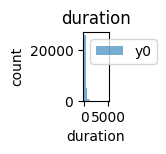

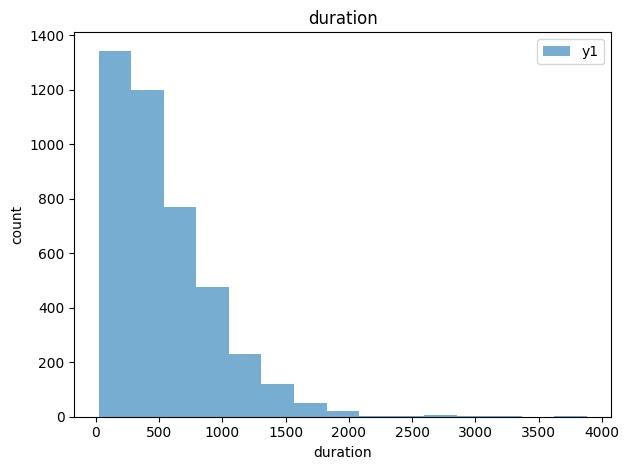

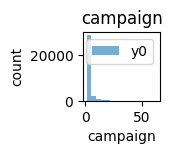

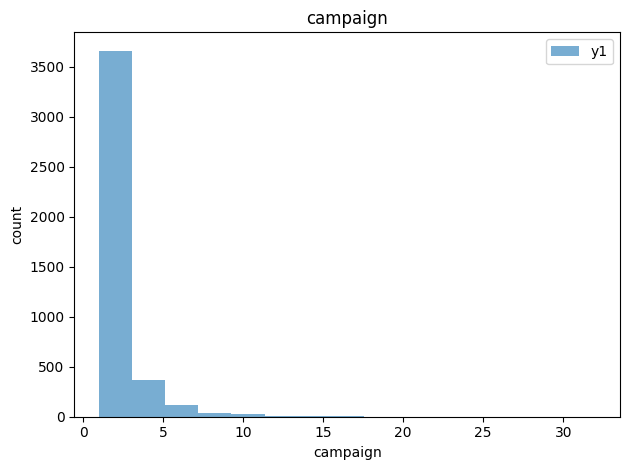

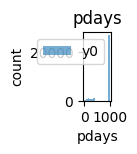

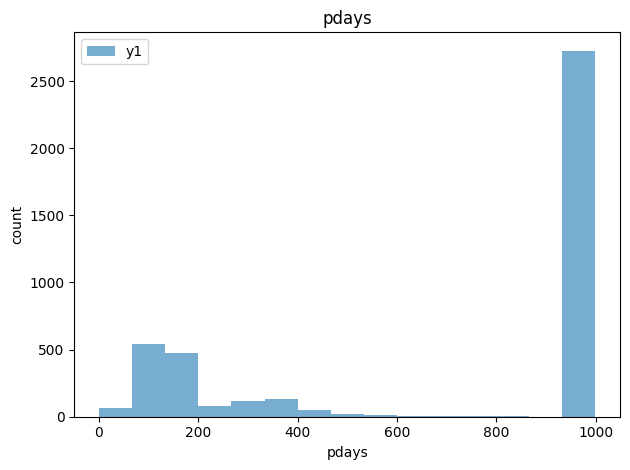

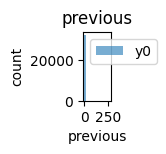

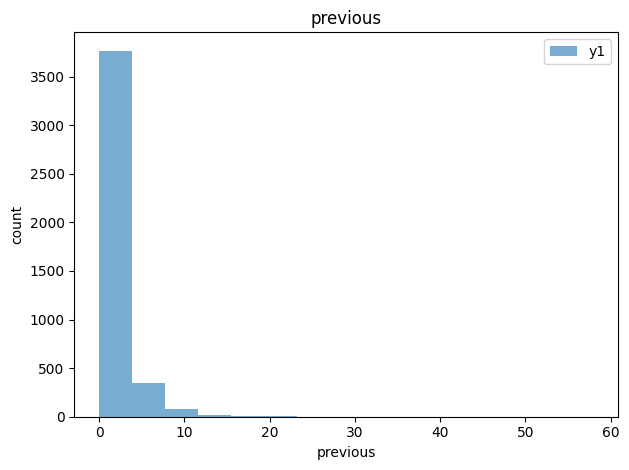

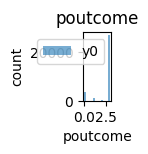

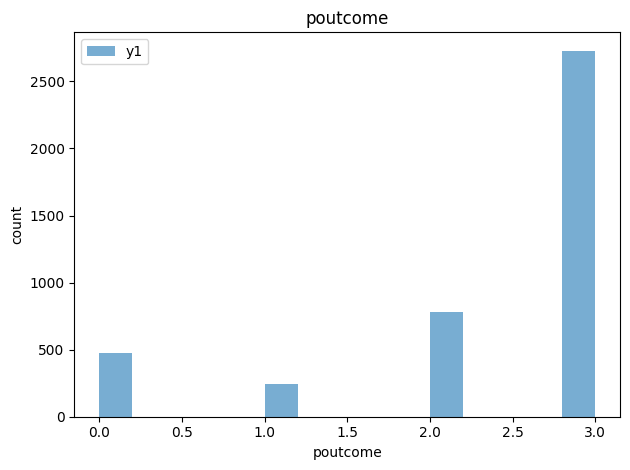

In [9]:
import matplotlib.pyplot as plt
features=df.columns.drop('y')
rows =4
cols=6
plt.figure(figsize =(15,12))

for i,feature in enumerate (features):
    plt.subplot(rows,cols,i+1)
    for label in df['y'].unique():
        subset=df[df['y']==label]
        plt.hist(subset[feature],bins=15,alpha=0.6,label =f'y{label}')
        plt.title(feature)
        plt.xlabel(feature)
        plt.ylabel('count')
        plt.legend()
        plt.tight_layout()
        plt.show()
        
       

# Set up grid layout: 6 rows x 4 columns (22 plots)

    

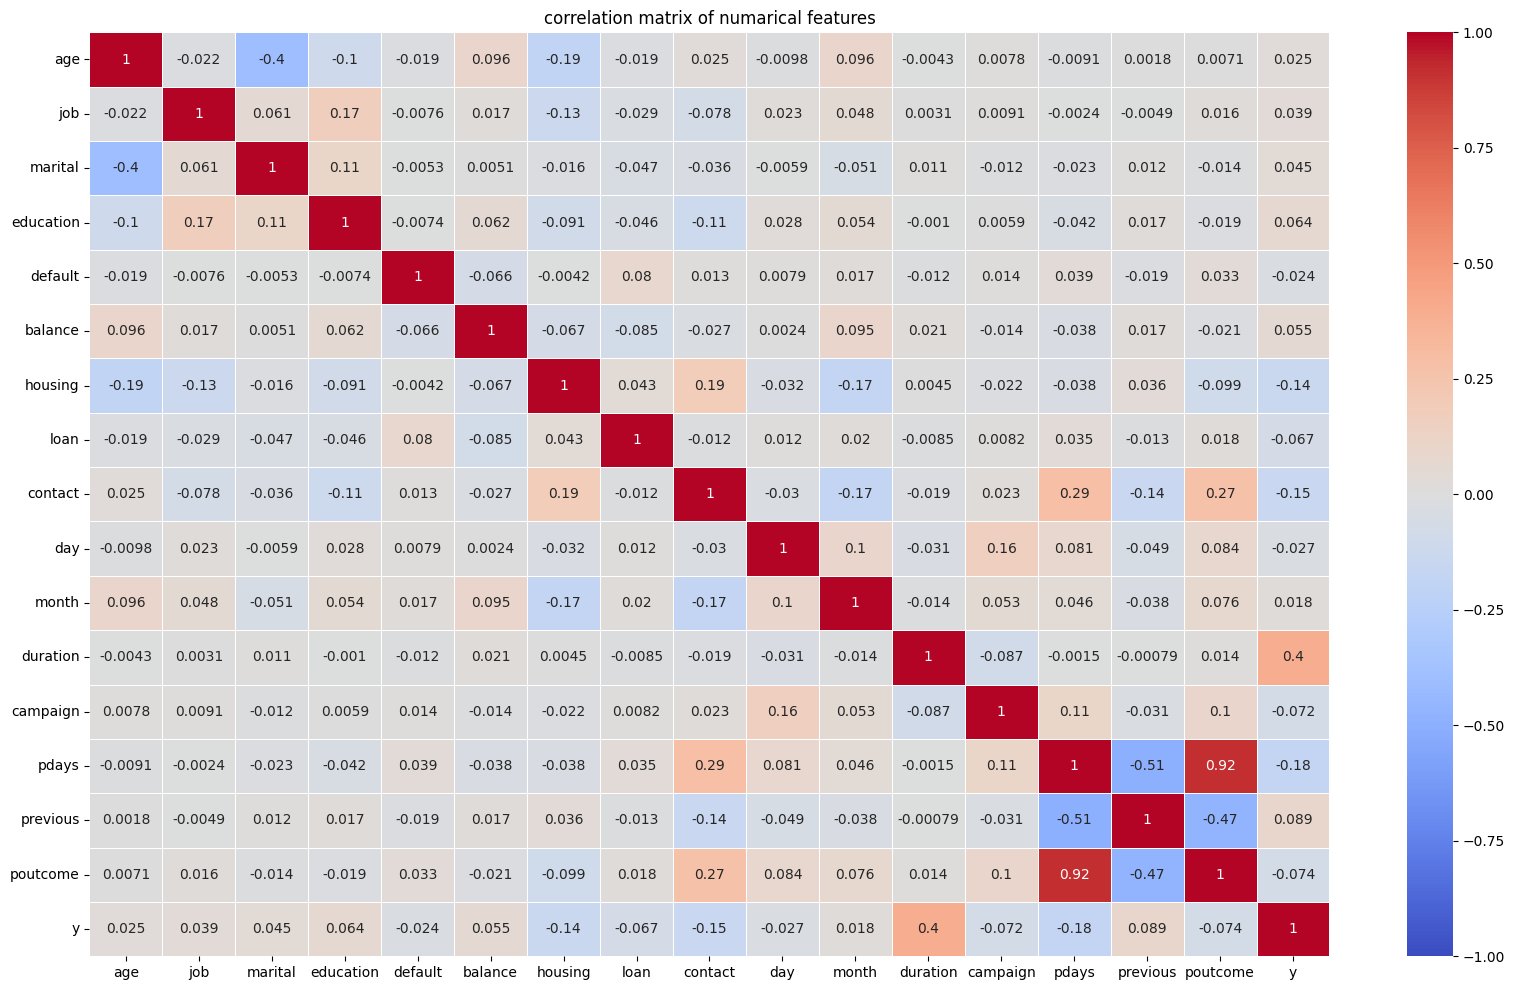

Highly correlated numarical features (>0.7) :  [('pdays', 'poutcome')]


In [10]:
import seaborn as sns
numarical_features =df.select_dtypes(include=['int64']).columns
corr_matrix = df[numarical_features].corr()

plt.figure(figsize=(20,12))
sns.heatmap(corr_matrix ,annot = True,cmap="coolwarm",vmin=-1,vmax=1,linewidths=0.5)
plt.title("correlation matrix of numarical features")
plt.show()


high_corr = np.where(np.abs(corr_matrix)>0.7)
high_corr_features = [(numarical_features[i],numarical_features[j])for i,j in zip(*high_corr) if i!=j and i<j]
print("Highly correlated numarical features (>0.7) : ",high_corr_features)


/tmp/ipykernel_57/3826250295.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_y.values,y=correlation_with_y.index,palette='coolwarm')


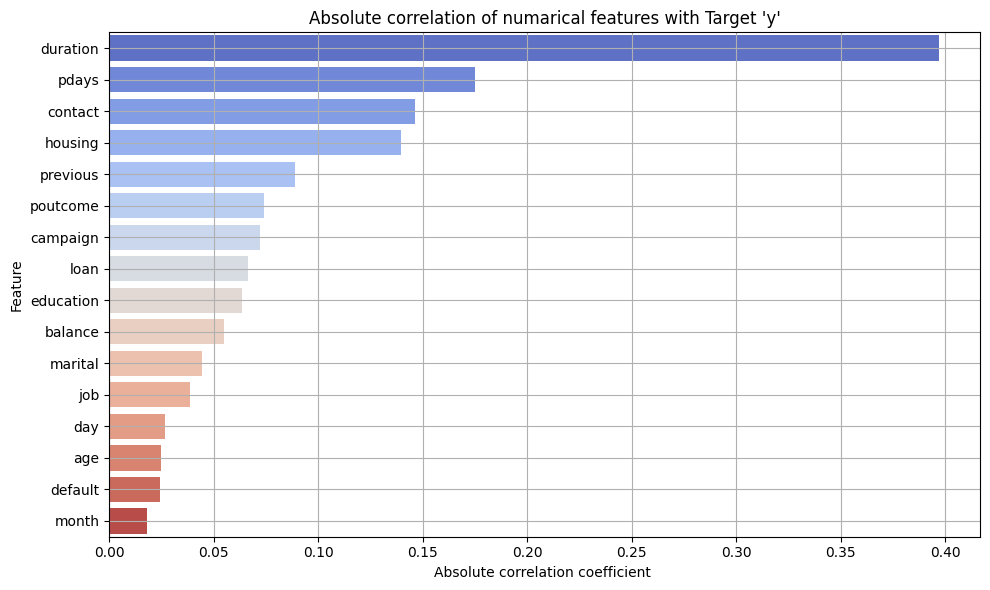

In [11]:
numarical_features = df.select_dtypes(include=['int64']).columns
correlation_with_y = df[numarical_features].corr()['y'].drop('y').abs()
correlation_with_y =correlation_with_y.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=correlation_with_y.values,y=correlation_with_y.index,palette='coolwarm')
plt.title("Absolute correlation of numarical features with Target 'y'")
plt.xlabel("Absolute correlation coefficient ")
plt.ylabel("Feature")
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:

print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


<Axes: >

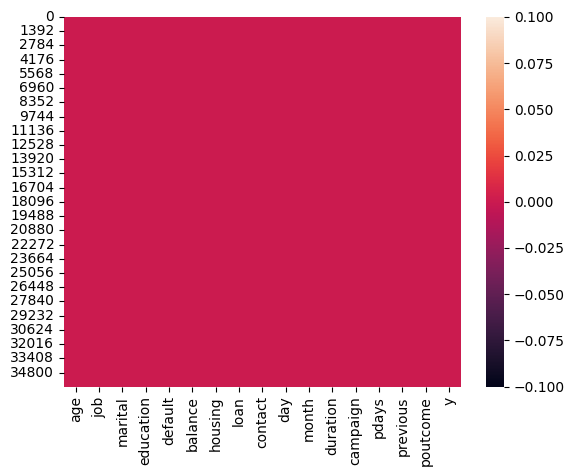

In [13]:
sns.heatmap(df.isnull())

In [14]:
from sklearn.feature_selection import SelectKBest,f_classif

x=df.drop('y',axis=1)
y=df['y']

k=10
selector=SelectKBest(score_func=f_classif,k=k)
x_new=selector.fit_transform(x,y)

selected_features = list(x.columns[selector.get_support()])
print(f"Top {k} selected features:",selected_features)


Top 10 selected features: ['education', 'balance', 'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']


/tmp/ipykernel_57/38781746.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x=feature,y='y',alpha=0.5,palette='coolwarm')
/tmp/ipykernel_57/38781746.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x=feature,y='y',alpha=0.5,palette='coolwarm')
/tmp/ipykernel_57/38781746.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x=feature,y='y',alpha=0.5,palette='coolwarm')
/tmp/ipykernel_57/38781746.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x=feature,y='y',alpha=0.5,palette='coolwarm')
/tmp/ipykernel_57/38781746.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x=feature,y='y',alpha=0.5,palette='coolwarm')
/tmp/ipykernel_57/38781746.py:8: UserWarning: Ignoring `palette` because no `hue` variable

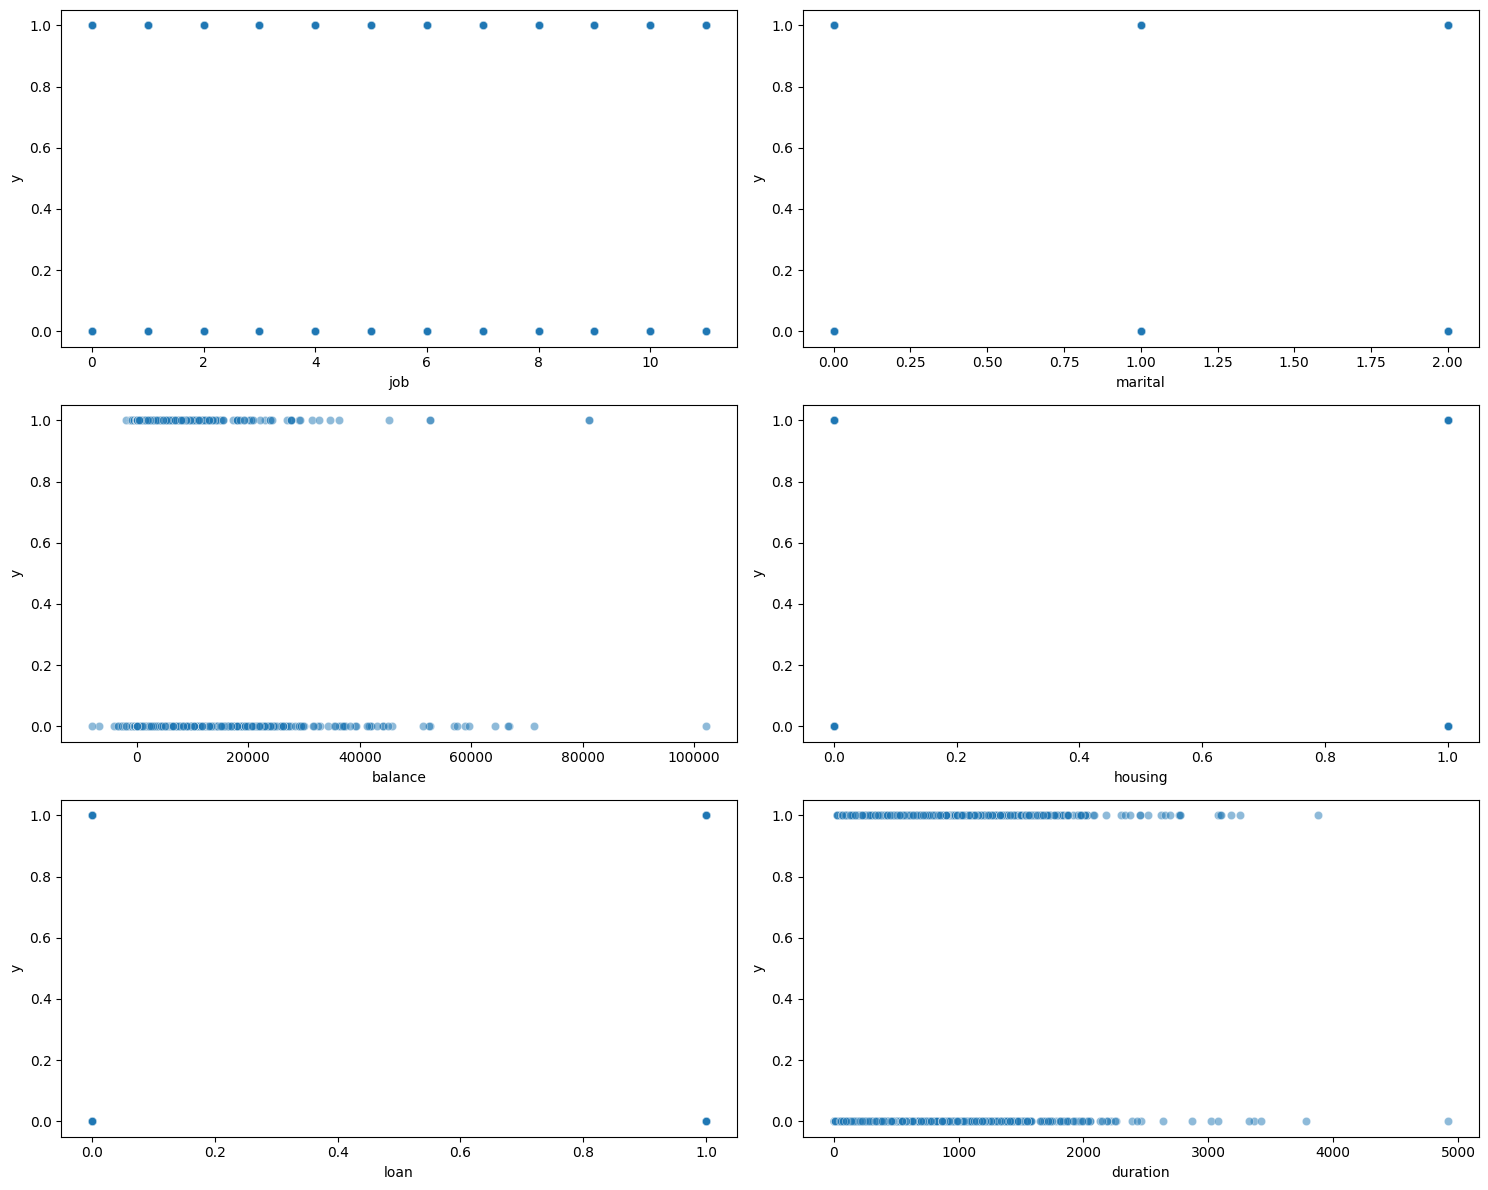

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns 
numeric_features = ['job','marital','balance','housing','loan','duration']

plt.figure(figsize=(15,12))
for i ,feature in enumerate(numeric_features):
  plt.subplot(3,2,i+1)
  sns.scatterplot(data=df,x=feature,y='y',alpha=0.5,palette='coolwarm')
  
plt.tight_layout()
plt.show()



/tmp/ipykernel_57/3174325005.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x=feature,y='y',alpha=0.5,palette='coolwarm')
/tmp/ipykernel_57/3174325005.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x=feature,y='y',alpha=0.5,palette='coolwarm')
/tmp/ipykernel_57/3174325005.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x=feature,y='y',alpha=0.5,palette='coolwarm')
/tmp/ipykernel_57/3174325005.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x=feature,y='y',alpha=0.5,palette='coolwarm')


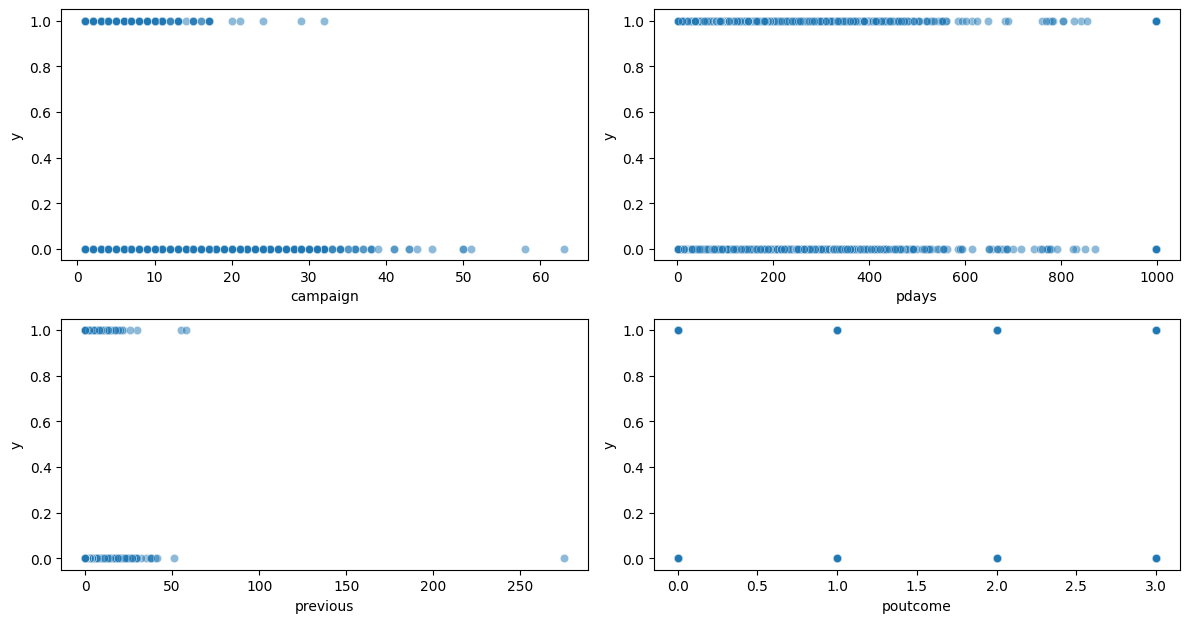

In [16]:
import matplotlib.pyplot as plt 
import seaborn as sns 
remaining = ['campaign','pdays','previous','poutcome']

plt.figure(figsize=(12,9))
for i,feature in enumerate(remaining):
    plt.subplot(3,2,i+1)
    sns.scatterplot(data=df,x=feature,y='y',alpha=0.5,palette='coolwarm')

plt.tight_layout()
plt.show()


In [17]:
df = df[selected_features +['y']]

print(df)


       education  balance  housing  loan  contact  duration  campaign  pdays  \
0              1      861        0     0        1       140         2    999   
1              1     4126        0     0        0       907         4    185   
2              1      244        1     0        0      1735         4    999   
3              1        0        0     0        1        35        11    999   
4              1      257        0     0        0        57        10    999   
...          ...      ...      ...   ...      ...       ...       ...    ...   
36163          1      917        1     0        0        58         2    999   
36164          1       22        1     0        0        77         5    999   
36165          1       79        1     0        0        98         1    999   
36166          2     2559        1     0        0       227         1    999   
36167          3      478        0     0        0       173         2    311   

       previous  poutcome  y  
0       

In [18]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36168 entries, 0 to 36167
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   education  36168 non-null  int64
 1   balance    36168 non-null  int64
 2   housing    36168 non-null  int64
 3   loan       36168 non-null  int64
 4   contact    36168 non-null  int64
 5   duration   36168 non-null  int64
 6   campaign   36168 non-null  int64
 7   pdays      36168 non-null  int64
 8   previous   36168 non-null  int64
 9   poutcome   36168 non-null  int64
 10  y          36168 non-null  int64
dtypes: int64(11)
memory usage: 3.0 MB


In [20]:
from sklearn.model_selection import train_test_split

x=df.drop('y',axis=1)
y= df['y']

x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix ,accuracy_score

np.random.seed(42)
x_train_scaled_ = x_train_scaled + np.random.normal(0,0.5,x_train_scaled.shape)
x_test_scaled_ = x_test_scaled + np.random.normal(0,0.5,x_test_scaled.shape)

model = LogisticRegression()
model.fit(x_train_scaled,y_train)
y_pred = model.predict(x_test_scaled)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("Accuracy:",accuracy_score(y_test,y_pred))


[[6240  148]
 [ 583  263]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      6388
           1       0.64      0.31      0.42       846

    accuracy                           0.90      7234
   macro avg       0.78      0.64      0.68      7234
weighted avg       0.88      0.90      0.88      7234

Accuracy: 0.8989494055847387


In [23]:
from sklearn.naive_bayes import GaussianNB

nb_model=GaussianNB()
nb_model.fit(x_train_scaled,y_train)
y_pred_nb=nb_model.predict(x_test_scaled)

print("Confusion matrix:\n",confusion_matrix(y_test,y_pred_nb))
print("\n Classification report : \n ",classification_report(y_test,y_pred_nb))
print("Accuracy: ",accuracy_score(y_test,y_pred_nb))


Confusion matrix:
 [[5689  699]
 [ 449  397]]

 Classification report : 
                precision    recall  f1-score   support

           0       0.93      0.89      0.91      6388
           1       0.36      0.47      0.41       846

    accuracy                           0.84      7234
   macro avg       0.64      0.68      0.66      7234
weighted avg       0.86      0.84      0.85      7234

Accuracy:  0.8413049488526403


In [24]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion = 'entropy',max_depth=4,random_state=1)
dtree.fit(x_train_scaled,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=1)

In [25]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

y_pred_dt=dtree.predict(x_test_scaled)
print("Confusion matrix : \n",confusion_matrix(y_test,y_pred_dt))
print("\n classification report : \n ",classification_report(y_test,y_pred_dt))
print("Accuracy: \n ",accuracy_score(y_test,y_pred_dt))


Confusion matrix : 
 [[6248  140]
 [ 601  245]]

 classification report : 
                precision    recall  f1-score   support

           0       0.91      0.98      0.94      6388
           1       0.64      0.29      0.40       846

    accuracy                           0.90      7234
   macro avg       0.77      0.63      0.67      7234
weighted avg       0.88      0.90      0.88      7234

Accuracy: 
  0.8975670445120265


In [26]:
results=pd.DataFrame({
    "Model":["Logistic Regression","Naive bayes","Decision Tree"],
    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,y_pred_nb),
        accuracy_score(y_test,y_pred_dt)
    ]
    
})

In [27]:
results=results.sort_values(by="Accuracy",ascending=False).reset_index(drop=True)
print(results)

                 Model  Accuracy
0  Logistic Regression  0.898949
1        Decision Tree  0.897567
2          Naive bayes  0.841305


                     Accuracy  Precision  Recall  F1 score   F1 score  Recall 
Logistic Regression     0.899      0.640   0.311      0.418       NaN      NaN
Naive Bayes             0.841      0.362   0.469        NaN     0.409      NaN
Decision Tree           0.898      0.636     NaN        NaN     0.398     0.29


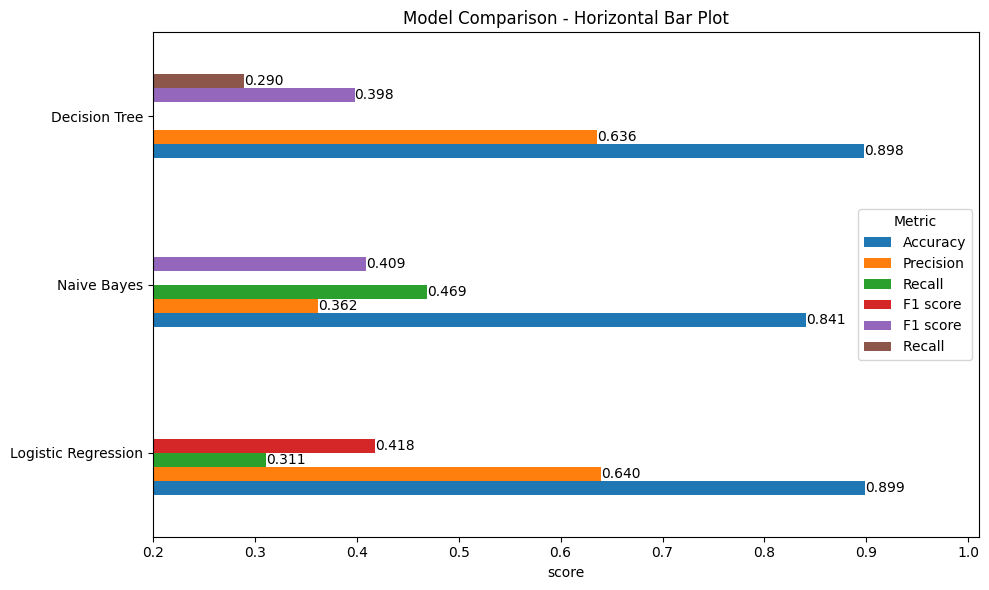

In [28]:
from sklearn.metrics import precision_score,recall_score,f1_score
results={}

logistic_pred = model.predict(x_test_scaled)
results['Logistic Regression']={
    'Accuracy': accuracy_score(y_test,logistic_pred),
    
    'Precision':precision_score(y_test,logistic_pred),
    'Recall': recall_score(y_test,logistic_pred),
     'F1 score ':f1_score(y_test,logistic_pred)

}

nb_pred = nb_model.predict(x_test_scaled)
results['Naive Bayes']={
    'Accuracy':accuracy_score(y_test,nb_pred),
    'Precision':precision_score(y_test,nb_pred),
     'Recall': recall_score(y_test,nb_pred),
     'F1 score':f1_score(y_test,nb_pred)
}
dt_pred=dtree.predict(x_test_scaled)
results['Decision Tree']={
    'Accuracy':accuracy_score(y_test,dt_pred),
    'Precision':precision_score(y_test,dt_pred),
     'Recall ':recall_score(y_test,dt_pred),
     'F1 score':f1_score(y_test,dt_pred)


}
results_df=pd.DataFrame(results).T
results_df=results_df.round(3)
print(results_df)
ax=results_df.plot(kind='barh',figsize=(10,6))
plt.title("Model Comparison - Horizontal Bar Plot")
plt.xlabel("score")
plt.xlim(0.2,1.01)

for container in ax.containers:
    ax.bar_label(container,fmt='%.3f')

plt.legend(title='Metric')
plt.tight_layout()
plt.show()

    

In [29]:
train_pred =dtree.predict(x_train_scaled)
train_acc = accuracy_score(y_train,train_pred)
print("Training Accuracy : ",train_acc)

test_pred = dtree.predict(x_test_scaled)
test_acc = accuracy_score(y_test,test_pred)
print ( "Test Accuracy",test_acc)


Training Accuracy :  0.8982511923688394
Test Accuracy 0.8975670445120265
